# Step 2 — Cross-patient clustering with Seurat: 11 ST clusters on TCGA

Takes the per-domain *averaged* expression profiles produced upstream (one row per `(slide, SpaGCN domain)` × one column per gene) and jointly clusters them across all TCGA-BRCA patients with the Seurat pipeline. Yields **11 ST clusters** consistent across patients.

The clustering parameters live in `../lib/clustering_helpers.R`; this notebook just orchestrates the call and visualizes the result. The cluster identity labels (`Cluster_1`…`Cluster_11`) are a frozen mapping from the numeric Seurat output so the cluster names match the paper across reruns.

**Inputs (replace paths with your own)**
- `target_seurat_all_genes.qs` — Seurat object with one cell per `(slide, domain)`, counts = mean expression of the domain. Built upstream from the SpaGCN outputs.

**Outputs**
- `tcga_target_seurat_all_genes_new.qs` — Seurat object with `seurat_clusters` (0–10) and `mapped_clusters` (`Cluster_1` … `Cluster_11`).
- `TCGA_mapped_clusters.csv` — table mapping each refined per-spot domain to its `mapped_clusters` label.
- `tsne_coords.csv` — per-domain t-SNE embedding for the figure below.

## Setup

In [ ]:
Sys.setenv(MKL_THREADING_LAYER = "GNU")
suppressPackageStartupMessages({
  library(presto)
  library(data.table)
  library(Seurat)
  library(qs)
  library(dplyr)
  library(ggplot2)
  library(scales)
})

source("../lib/clustering_helpers.R")

## Load the per-domain Seurat object

Each Seurat "cell" here is one SpaGCN domain on one slide; the count matrix entry is the mean expression of that gene across the domain's spots. Replace the path with your own copy.

In [ ]:
target <- qs::qread("/vf/users/Ruppin_ST/scr/TCGA_SpaGCN/target_seurat_all_genes.qs")
target

## Run the cross-patient clustering

`run_cross_patient_clustering()` applies the Seurat normalization + variable-feature selection + PCA + SNN graph + Louvain clustering pipeline.

In [ ]:
target <- run_cross_patient_clustering(target)
target <- apply_st_cluster_mapping(target)
table(Idents(target))

## Persist outputs

A CSV mapping each refined per-spot domain ID to its cluster (used downstream by the SpatioType notebook and by external cohorts that transfer these labels via `Seurat::TransferData`), plus the updated Seurat object.

In [ ]:
gg <- target@meta.data[, c("mapped_clusters", "slide_name"), drop = FALSE]
gg$refined_pred <- rownames(gg)
fwrite(gg, file = "/vf/users/Ruppin_ST/scr/pipline/TCGA_mapped_clusters.csv")
qsave(target, file = "/vf/users/Ruppin_ST/scr/TCGA_SpaGCN/tcga_target_seurat_all_genes_new.qs")

## t-SNE visualization of the 11 ST clusters

Reproduces the figure shown in the paper. The t-SNE coordinates are computed once on the per-domain PCA embedding and saved to `clustering/data/tsne.csv`; here we just load and plot.

To regenerate the coordinates from your own Seurat object, uncomment the `RunTSNE` block.

In [ ]:
# To recompute (optional):
# target <- RunTSNE(target, dims = 1:30, check_duplicates = FALSE)
# tsne_df <- data.frame(
#   tSNE_1  = Embeddings(target, "tsne")[, 1],
#   tSNE_2  = Embeddings(target, "tsne")[, 2],
#   Cluster = as.integer(gsub("Cluster_", "", target@meta.data$mapped_clusters))
# )
# fwrite(tsne_df, "../data/tsne.csv", row.names = TRUE)

tsne_df <- fread("../data/tsne.csv")
setnames(tsne_df, "V1", "refined_pred")
tsne_df$Cluster <- factor(tsne_df$Cluster, levels = sort(unique(tsne_df$Cluster)))
head(tsne_df)

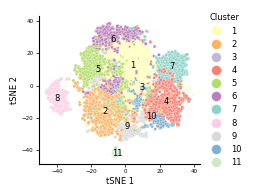

In [1]:
# Paper palette (matches the published figure)
cluster_colors <- c(
  '#FFFFB3', '#FDB462', '#BEBADA', '#FB8072', '#B3DE69',
  '#BC80BD', '#8DD3C7', '#FCCDE5', '#D9D9D9', '#80B1D3', '#CCEBC5'
)

centroids <- tsne_df %>%
  group_by(Cluster) %>%
  summarise(tSNE_1 = median(tSNE_1), tSNE_2 = median(tSNE_2), .groups = 'drop')

options(repr.plot.width = 4.5, repr.plot.height = 3.2)
ggplot(tsne_df, aes(x = tSNE_1, y = tSNE_2, color = Cluster)) +
  geom_point(size = 0.6, alpha = 0.85) +
  geom_text(data = centroids, aes(label = Cluster), color = 'black', size = 2.5) +
  scale_color_manual(values = cluster_colors) +
  guides(color = guide_legend(override.aes = list(size = 2.5))) +
  theme_classic(base_size = 7) +
  theme(
    legend.key.size = unit(0.3, 'cm'),
    legend.position = 'right'
  ) +
  labs(x = 'tSNE 1', y = 'tSNE 2', color = 'Cluster')

## (Optional) Marker analysis

`FindAllMarkers` with MAST yields the per-cluster differentially expressed genes used in the paper's biological interpretation of each ST cluster.

In [ ]:
all_markers <- FindAllMarkers(target, only.pos = FALSE, test.use = "MAST")
fwrite(all_markers, file = "all_markers_MAST.csv")
head(all_markers)